### Handling Missing Data(Numerical) by Imputation

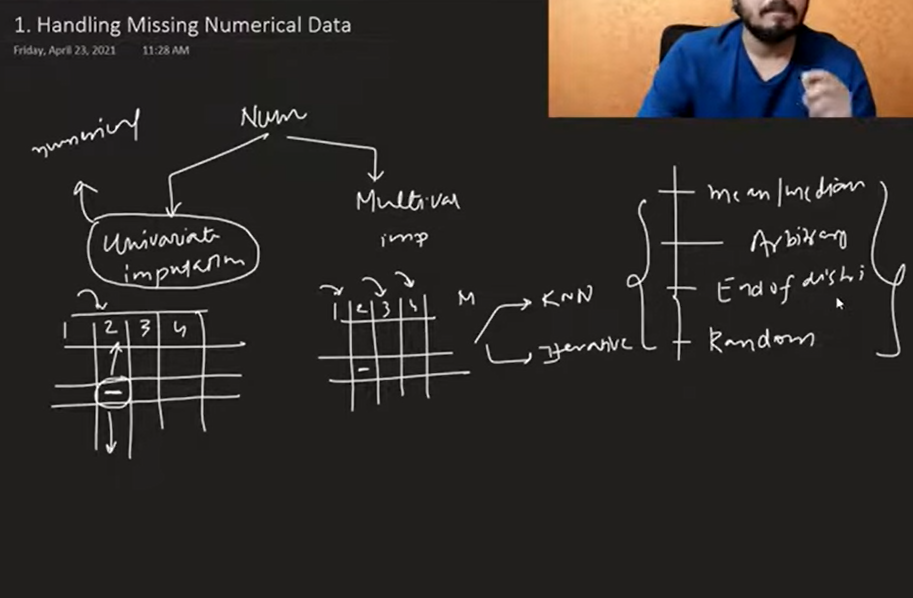

univariate: ager ap aik col. ki missing value fill kerny k liay ussi col. ki values ki help lo
multivariate: aik col. ki missing value fill kerny k liay sth wlo ki bhi help lo

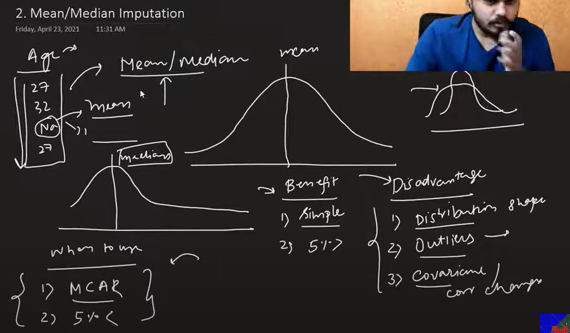

> If data is normalized(upper graph in pic) use mean imputation\
if data is Skewed use Median imputation

> Simplicity means ky jab website deploy kerty hain tb bhi isko implement kerna easy hota ha

> 5% sy zyda missing values hon _to not good_

> Outliers ajaty ha

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv("titanic_toy.csv")

In [6]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [8]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

* Abey bhai bhoolgya uper _percentage_ check kerni ha???

In [10]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [13]:
X=df.drop(columns=["Survived"])
y=df["Survived"]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [17]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [19]:
X_train.isnull().mean()

Age       0.198034
Fare      0.054775
Family    0.000000
dtype: float64

> * Jb bhi mean/median imputation lagyingy kisi data py uska ___VARIANCE___ Shrink ker jyga

> * __Point to be noted is ky zyda shrink na kery__

> * ALso there should not be drastic changes

#### Applying mean and median imputation

In [24]:
# Calculating mean and median of Age Column
mean_age=X_train["Age"].mean()
median_age=X_train['Age'].median()
# Calculating mean and median of Fare Column
mean_fare=X_train["Age"].mean()
median_fare=X_train['Fare'].median()

In [29]:
X_train["Age_Mean"]=X_train['Age'].fillna(mean_age)
X_train['Age_Median']=X_train['Age'].fillna(median_age)

X_train['Fare_Mean']=X_train["Fare"].fillna(mean_fare)
X_train['Fare_Median']=X_train["Fare"].fillna(median_fare)

In [30]:
X_train

,Age,Fare,Family,Age_Mean,Age_Median,Fare_Mean,Fare_Median
140,NaN,15.2458,2,29.745184,29.0,15.245800,15.2458
439,31.0,10.5000,0,31.000000,31.0,10.500000,10.5000
817,31.0,37.0042,2,31.000000,31.0,37.004200,37.0042
378,20.0,NaN,0,20.000000,20.0,29.745184,14.4542
491,21.0,7.2500,0,21.000000,21.0,7.250000,7.2500
...,...,...,...,...,...,...,...
835,39.0,83.1583,2,39.000000,39.0,83.158300,83.1583
192,19.0,7.8542,1,19.000000,19.0,7.854200,7.8542
629,NaN,7.7333,0,29.745184,29.0,7.733300,7.7333
559,36.0,17.4000,1,36.000000,36.0,17.400000,17.4000


* Checking Variance before and after

In [31]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_Median'].var())
print('Age Variance after mean imputation: ', X_train['Age_Mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_Median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_Mean'].var())

Original Age variable variance:  213.7165085187575
Age Variance after median imputation:  171.42222438960792
Age Variance after mean imputation:  171.33390978297015
Original Fare variable variance:  2574.352620663723
Fare Variance after median imputation:  2448.8970247777565
Fare Variance after mean imputation:  2433.3808760626516


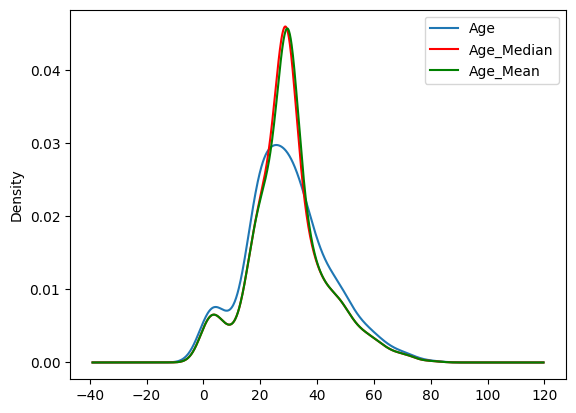

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_Median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_Mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

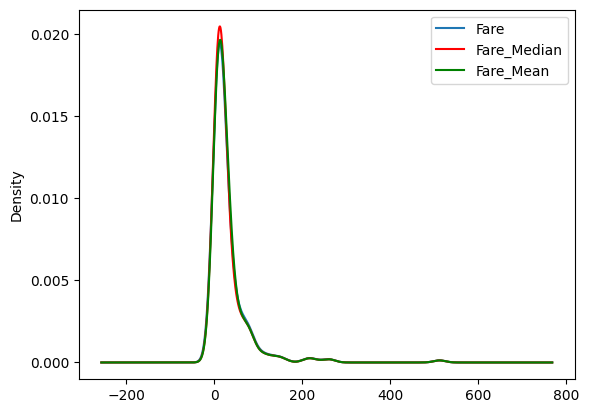

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_Median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_Mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [38]:
X_train.cov()

,Age,Fare,Family,Age_Mean,Age_Median,Fare_Mean,Fare_Median
Age,213.716509,84.480223,-6.393469,213.716509,213.716509,79.552618,79.420930
Fare,84.480223,2574.352621,17.050423,67.493301,68.754981,2574.352621,2574.352621
Family,-6.393469,17.050423,2.770177,-5.125566,-5.121468,16.136035,16.285129
Age_Mean,213.716509,67.493301,-5.125566,171.333910,171.333910,63.776361,63.670788
Age_Median,213.716509,68.754981,-5.121468,171.333910,171.422224,64.964969,64.831778
Fare_Mean,79.552618,2574.352621,16.136035,63.776361,64.964969,2433.380876,2435.077578
Fare_Median,79.420930,2574.352621,16.285129,63.670788,64.831778,2435.077578,2448.897025


### Using Sklearn

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [40]:
imputer1= SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [44]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,["Fare"])
],remainder='passthrough')

In [45]:
trf.fit(X_train)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [ ]:
#named_transformer ---> to access the fitted transformer by name

trf.named_transformers_['imputer1'].statistics_
#the output is the median of age

array([28.75])

In [ ]:
trf.named_transformers_['imputer2'].statistics_

#the output is the mean of Fare

array([32.61759689])

In [48]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [49]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

In [51]:
X_train['Age'].var()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices